## Author: Gabriel Vance

## Class: DSC630 - Predictive Analytics

## Professor: Professor Amirfarrokh Iranitalab

## Date: January 17, 2026

## Fake News Detection Using NLP Techniques


## I. Business Understanding


Background

Lies have always been a part of human society and communication. Simply put, lies are saying something that is not true. Fake news is another term for lies. It presents itself as a legitimate update in the world without maintain a factual basis.

When journalism and technology merged, the dispersion of fake news changed from supermarket tabloids and talk radio to webpages, social media, and now AI generated content. It is increasingly more believable, viral, and widespread. Foreign states, activists, and grifters are spreading fake news to achieve their political, influential and financial ends. But while technology is partially responsible for the rise and proliferation of fake news, it can also substantially aid in combating these lies.

For my project, I chose to use a natural language processor to identify fake news. The assumption was that fake news or lies contained a certain language or pattern structure that stood out from truthful news. This is likely due to fake news largely being “spam” or manufactured news, so in essence, machines were generating fake news and left a “watermark” that was easily predictable, like spam or malware.
For imports, we will use traditional python data analysis tools as well as the NLP libraries Textblob and VADER. For prediction, we will use sklearn.

Business Objective: Achieve 75% accuracy in predicting fake news.


### Imports


In [1]:
# Standard library
import re
from collections import Counter
import warnings

# Data manipulation and analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Statistics
from scipy.stats import skew, kurtosis, ttest_ind

# Text processing / NLP
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
    TfidfVectorizer,
    CountVectorizer,
)
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from xgboost import XGBClassifier


# Domain extraction
import tldextract

# Jupyter display tweaks
from IPython.core.display import display, HTML

# Suppress warnings for cleaner output
import os
import warnings
from tqdm import TqdmWarning
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=TqdmWarning)
# Suppress DeprecationWarning and TqdmWarning specifically
warnings.filterwarnings("ignore", category=DeprecationWarning) # I tried to silence, but it still shows up
os.environ["TQDM_DISABLE"] = "1"


from IPython.core.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
# Ensure that all code cells are fully visible without scrolling

/var/folders/11/dxk146610qn60jn0f0xly1800000gn/T/ipykernel_21613/610129518.py:56: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


### II. Data Understanding


#### Collection


The dataset for this notebook was provided by https://www.kaggle.com/datasets/algord/fake-news. I intentionally chose one of the most popular datasets on Kaggle that has already been downloaded over 10,000 times. The dataset contains 626 real news articles and 434 fake news articles. The news articles themselves have been fact-checked by PolitiFact.

It's important to note that this dataset is crucial to understanding how fake news detectors work. The dataset must be vetted and peer reviewed to avoid having a biased set that will influence the model. One bad data point won't throw off the model, but a strong pattern or trend will corrupt the model. Future models might opt for different datasets to verify fake news can be detected on different sources. These news articles were mostly from the 2016 election year.


#### Description

Examine the data and document its surface properties like data format, number of records, or field identities.


In [2]:
# Read data in
politics_real_df = pd.read_csv("github_set1/politifact_real.csv")
politics_fake_df = pd.read_csv("github_set1/politifact_fake.csv")

# Examine the shape of data
politics_real_df.head()

,id,news_url,title,tweet_ids
0,politifact14984,http://www.nfib-sbet.org/,National Federation of Independent Business,967132259869487105\t967164368768196609\t967215...
1,politifact12944,http://www.cq.com/doc/newsmakertranscripts-494...,comments in Fayetteville NC,942953459\t8980098198\t16253717352\t1668513250...
2,politifact333,https://web.archive.org/web/20080204072132/htt...,"Romney makes pitch, hoping to close deal : Ele...",NaN
3,politifact4358,https://web.archive.org/web/20110811143753/htt...,Democratic Leaders Say House Democrats Are Uni...,NaN
4,politifact779,https://web.archive.org/web/20070820164107/htt...,"Budget of the United States Government, FY 2008",89804710374154240\t91270460595109888\t96039619...


#### Description Conclusion

The dataset contains the following columns:

- id - unique identifier for each article
- news_url - news source URL
- title - title of the article
- text - text of the article
- tweet_ids - tweet IDs associated with the article. to find the tweet, append the id to https://twitter.com/i/web/status/{{tweet_id}} i.e. https://twitter.com/i/web/status/284329075902926848

Each row is a single instance of an article. The title is the headline of the article. The news url is the source of the article. Tweet IDs are the number of tweets that shared the article. Other fake news datasets contain the actual text of the article, but this isn't required for classifying fake news. Using only the title allows us to expedite model comparison and training time.

Tweet IDs can be used for manually looking up the actual tweet via the twitter API/URL.


#### Explore Data (Tweet IDs)


The tweet IDs are separated by white space or '\t'. We'll separate them to get the number of tweets per article.


In [3]:
# Create number of tweets column to understand engagement, set to 0 if no tweets
politics_real_df["number_of_tweets"] = politics_real_df["tweet_ids"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split("\t"))
)
politics_fake_df["number_of_tweets"] = politics_fake_df["tweet_ids"].apply(
    lambda x: 0 if pd.isna(x) else len(str(x).split("\t"))
)
politics_real_df[["tweet_ids", "number_of_tweets"]].head()

,tweet_ids,number_of_tweets
0,967132259869487105\t967164368768196609\t967215...,1174
1,942953459\t8980098198\t16253717352\t1668513250...,51
2,NaN,0
3,NaN,0
4,89804710374154240\t91270460595109888\t96039619...,8


With the new number_of_tweets column, we can analyze the engagement of real vs fake news articles.


In [4]:
# Calculate mean number of tweet_ids for fake and real dataframes
mean_fake_tweet_ids = politics_fake_df["number_of_tweets"].mean()
mean_real_tweet_ids = politics_real_df["number_of_tweets"].mean()

print(f"Mean # of tweet_ids (fake): {mean_fake_tweet_ids:.2f}")
print(f"Mean # of tweet_ids (real): {mean_real_tweet_ids:.2f}")

Mean # of tweet_ids (fake): 382.76
Mean # of tweet_ids (real): 670.13


The presence of 0s is very much essential to understanding news proliferation. We'll compare the sum of articles that were tweeted 0 times in both datasets.


In [5]:
# Calculate number and percentage of articles with 0 tweets in both datasets
num_fake_zeros = (politics_fake_df["number_of_tweets"] == 0).sum()
num_real_zeros = (politics_real_df["number_of_tweets"] == 0).sum()

# Calculate percentages to see what portion of each dataset has 0 tweets
percent_fake_zeros = num_fake_zeros / len(politics_fake_df) * 100
percent_real_zeros = num_real_zeros / len(politics_real_df) * 100

print(
    f"Number of fake articles with 0 tweets: {num_fake_zeros} ({percent_fake_zeros:.2f}%)"
)
print(
    f"Number of real articles with 0 tweets: {num_real_zeros} ({percent_real_zeros:.2f}%)"
)

Number of fake articles with 0 tweets: 40 (9.26%)
Number of real articles with 0 tweets: 215 (34.46%)


Without standardization, the mean tweets for real news articles is higher than that of fake news articles. When comparing articles with 0 tweets, we see that more than 30% of all real articles have 0 tweets whereas only 9% of fake articles have 0 tweets. We'll standardize the number of tweets and conduct another comparison of mean tweets.


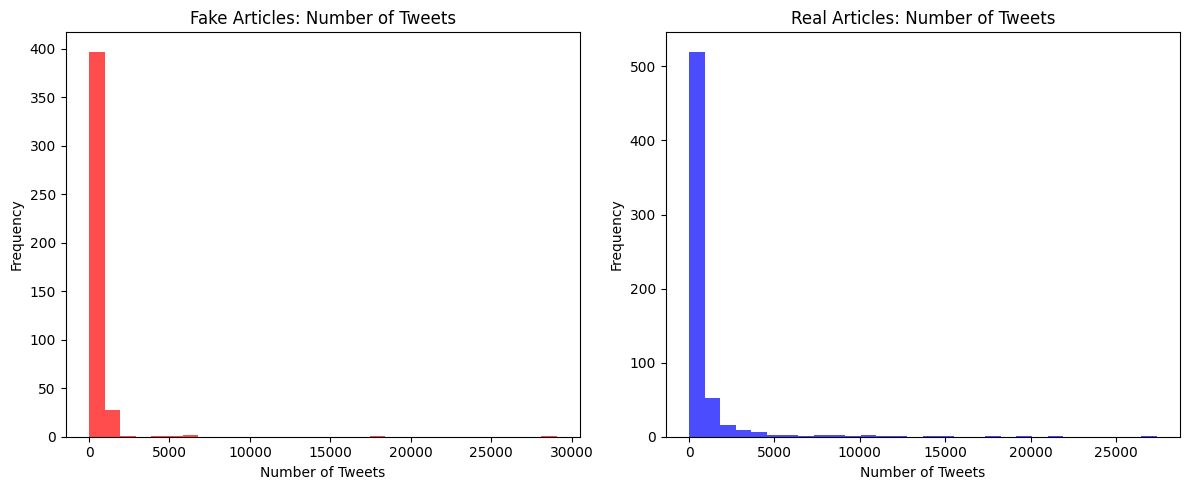

In [6]:
plt.figure(figsize=(12, 5))

# Plot histogram for fake articles
plt.subplot(1, 2, 1)
plt.hist(politics_fake_df["number_of_tweets"], bins=30, color="red", alpha=0.7)
plt.title("Fake Articles: Number of Tweets")
plt.xlabel("Number of Tweets")
plt.ylabel("Frequency")

# Do the same but for real articles
plt.subplot(1, 2, 2)
plt.hist(politics_real_df["number_of_tweets"], bins=30, color="blue", alpha=0.7)
plt.title("Real Articles: Number of Tweets")
plt.xlabel("Number of Tweets")
plt.ylabel("Frequency")

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

In [7]:
# Skewness and kurtosis for number_of_tweets. This will show us how the data is distributed.
fake_skew = skew(politics_fake_df["number_of_tweets"])
real_skew = skew(politics_real_df["number_of_tweets"])
# Calculate kurtosis
fake_kurt = kurtosis(politics_fake_df["number_of_tweets"])
real_kurt = kurtosis(politics_real_df["number_of_tweets"])

print(f"Fake Articles - Skewness: {fake_skew:.2f}, Kurtosis: {fake_kurt:.2f}")
print(f"Real Articles - Skewness: {real_skew:.2f}, Kurtosis: {real_kurt:.2f}")

Fake Articles - Skewness: 13.16, Kurtosis: 196.74
Real Articles - Skewness: 6.55, Kurtosis: 52.10


Fake news' kurtosis for number of tweets is significantly higher. The number of tweets for real news, while skewed, is more natural and less extremely skewed.


In [8]:
# Display descriptive statistics for number_of_tweets
print("Fake Articles - Number of Tweets Distribution:")
print(politics_fake_df["number_of_tweets"].describe())
print("\nReal Articles - Number of Tweets Distribution:")
print(politics_real_df["number_of_tweets"].describe())

Fake Articles - Number of Tweets Distribution:
count      432.000000
mean       382.759259
std       1728.420580
min          0.000000
25%         12.000000
50%         79.000000
75%        291.500000
max      29060.000000
Name: number_of_tweets, dtype: float64

Real Articles - Number of Tweets Distribution:
count      624.000000
mean       670.134615
std       2357.062320
min          0.000000
25%          0.000000
50%          8.000000
75%        167.000000
max      27377.000000
Name: number_of_tweets, dtype: float64


Just to get a sense of the types of articles, we'll look at the 5 articles with 0 retweet and the top 5 tweeted articles.


In [9]:
# Titles with number_of_tweets == 0 (first 5)
print("Titles with 0 tweets (first 5):")
# Filter and print titles with 0 tweets
for title in politics_real_df[politics_real_df["number_of_tweets"] == 0]["title"].head(
    5
):
    print(title)

# Titles with highest number_of_tweets (top 5)
print("\nTitles with highest tweet counts (top 5):")
# Just get the top 5 titles with highest number_of_tweets
for title in politics_real_df.sort_values("number_of_tweets", ascending=False)[
    "title"
].head(5):
    print(title)

Titles with 0 tweets (first 5):
Romney makes pitch, hoping to close deal : Elections : The Rocky Mountain News
Democratic Leaders Say House Democrats Are United Against GOP Default Act
子供たちのコト。私のコト。
Covering Young Adults Under the Affordable Care Act: The Importance of Outreach and Medicaid Expansion
Summary of the Affordable Care Act

Titles with highest tweet counts (top 5):
One in Four – Congressman Joe Pitts – Medium
Rep. Michael McCaul (R-TX) Appears on Face the Nation
Outlook, Office, Skype, Bing, Breaking News, and Latest Videos
interview on Fox News
"One Hundred Percent" by Club for Growth Action


Because the number of tweets contains 0, we'll use np.log1p to standardize the data. I chose log1p because it handles 0 values by applying log(1 + x). This allows us to transform the data without losing any instances.


In [10]:
# Apply log transformation to number_of_tweets to reduce skewness. Save this to new column to avoid dropping data.
politics_real_df["number_of_tweets_log"] = np.log1p(
    politics_real_df["number_of_tweets"]
)
politics_fake_df["number_of_tweets_log"] = np.log1p(
    politics_fake_df["number_of_tweets"]
)

Now we can repeat our histogram of the number of tweets, this time with less skewed data.


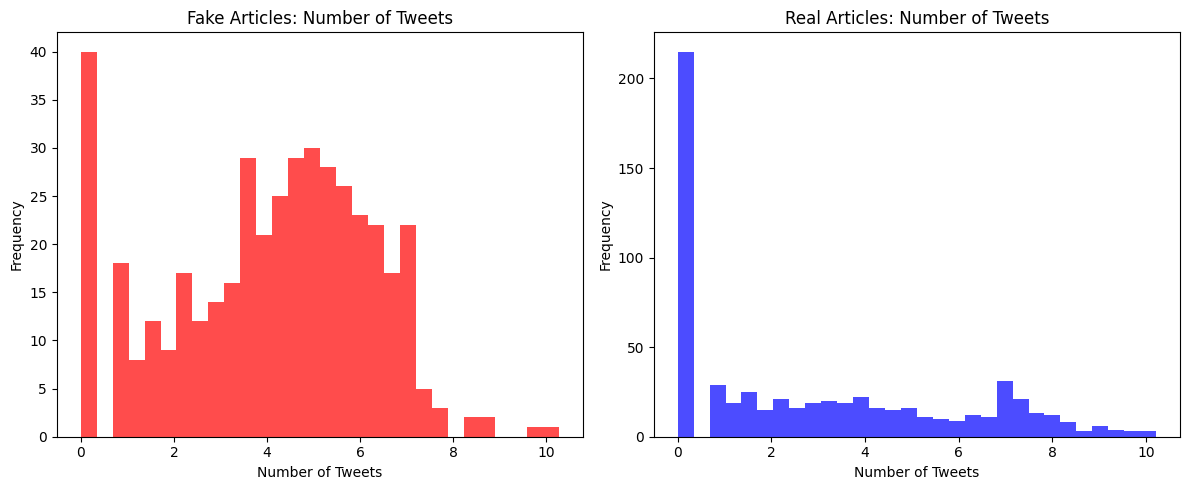

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(politics_fake_df["number_of_tweets_log"], bins=30, color="red", alpha=0.7)
plt.title("Fake Articles: Number of Tweets")
plt.xlabel("Number of Tweets")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(politics_real_df["number_of_tweets_log"], bins=30, color="blue", alpha=0.7)
plt.title("Real Articles: Number of Tweets")
plt.xlabel("Number of Tweets")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

log1p appears to given us the best distribution for number of tweets, as both the real and fake articles are closer to 0. The fake news articles are still still skewed but show a much more normal distribution compared to real news. News with 0 tweets will remain in our dataset but their importance has been noted as they are the primary reason for the skewness.


In [12]:
# Calculate mean number of tweet_ids for fake and real dataframes
mean_fake_tweet_ids = politics_fake_df["number_of_tweets_log"].mean()
mean_real_tweet_ids = politics_real_df["number_of_tweets_log"].mean()

print(f"Mean # of tweet_ids (fake): {mean_fake_tweet_ids:.2f}")
print(f"Mean # of tweet_ids (real): {mean_real_tweet_ids:.2f}")

Mean # of tweet_ids (fake): 4.04
Mean # of tweet_ids (real): 2.90


In [13]:
# Skewness and kurtosis for number_of_tweets
fake_skew_log = skew(politics_fake_df["number_of_tweets_log"])
real_skew_log = skew(politics_real_df["number_of_tweets_log"])
fake_kurt_log = kurtosis(politics_fake_df["number_of_tweets_log"])
real_kurt_log = kurtosis(politics_real_df["number_of_tweets_log"])

print("Before Log Transformation:")

print(f"Fake Articles - Skewness: {fake_skew:.2f}, Kurtosis: {fake_kurt:.2f}")
print(f"Real Articles - Skewness: {real_skew:.2f}, Kurtosis: {real_kurt:.2f}")

print("\nAfter Log Transformation:")

print(f"Fake Articles - Skewness: {fake_skew_log:.2f}, Kurtosis: {fake_kurt_log:.2f}")
print(f"Real Articles - Skewness: {real_skew_log:.2f}, Kurtosis: {real_kurt_log:.2f}")

Before Log Transformation:
Fake Articles - Skewness: 13.16, Kurtosis: 196.74
Real Articles - Skewness: 6.55, Kurtosis: 52.10

After Log Transformation:
Fake Articles - Skewness: -0.30, Kurtosis: -0.62
Real Articles - Skewness: 0.61, Kurtosis: -0.95


#### Explore Data (Tweet IDs) Conclusion

After normalizing, we notice that fake news on average is tweeted higher. Before normalization, real news was tweeted almost twice as much as fake news. How is this possible if 1/3 of all real news has 0 tweets? The likely answer is that a small subset of real news is tweeted tens of thousands of times, so much so that they carry the average tweet count higher than fake news. When standardized, we see that fake news on average is tweeted about 4.04 times vs real news averaging 2.9 tweets. Fake news is tweeted 38% more times than real news.


#### Explore Data (Domains)


Domains are the source of news articles. Similiar to targeting drug dealers over users, understanding the source of fake news is more useful than combatting the ways it is spread. Fake news itself is broadcasted on mediums such as X (Twitter), Facebook, and YouTube, but the origin of these articles is where the fake news begins. By understanding domains related to fake news, we can better classify fake vs real data sources.


In [14]:
# Some domains are empty, so we'll treat them as empty strings. Else, we can extract domain and suffix using tldextract.

# Extract domains and suffixes for each dataset
for label, df in [("fake", politics_fake_df), ("real", politics_real_df)]:
    df["domain"] = df["news_url"].apply(
        lambda x: tldextract.extract(str(x)).domain if pd.notnull(x) else ""
    )
    df["suffix"] = df["news_url"].apply(
        lambda x: tldextract.extract(str(x)).suffix if pd.notnull(x) else ""
    )
    print(
        f"{label.capitalize()} → {df['domain'].nunique()} unique domains, {df['suffix'].nunique()} unique suffixes"
    )


"""
It's possible that some domains will overlap while others will be unique to fake or real news.
We will conduct a comparison of domains and suffixes between fake and real datasets to identify overlaps and unique entries.
"""

# Convert to sets for overlap analysis
fake_domains = set(politics_fake_df["domain"].dropna())
real_domains = set(politics_real_df["domain"].dropna())
fake_suffixes = set(politics_fake_df["suffix"].dropna())
real_suffixes = set(politics_real_df["suffix"].dropna())

# --- DOMAIN OVERLAP ---
# Now we can find the domains that are common vs unique to each dataset
common_domains = fake_domains & real_domains
unique_fake_domains = fake_domains - real_domains
unique_real_domains = real_domains - fake_domains

# Print the number of each to get an idea of the raw number. NOTE: THIS IS THE RAW NUMBER and not the percentage of total domains.
print("\n DOMAIN COMPARISON")
print(f"Common domains: {len(common_domains)}")
print(f"Unique to fake: {len(unique_fake_domains)}")
print(f"Unique to real: {len(unique_real_domains)}")

# Just to give us a general list of some domains, we'll print a few examples
print("\nExamples of overlapping domains:", list(common_domains)[:10])
print("Examples unique to fake:", list(unique_fake_domains)[:10])
print("Examples unique to real:", list(unique_real_domains)[:10])

# We'll repeat the same process for suffixes, calculating the same overlap vs unique counts
# --- SUFFIX OVERLAP ---
common_suffixes = fake_suffixes & real_suffixes
unique_fake_suffixes = fake_suffixes - real_suffixes
unique_real_suffixes = real_suffixes - fake_suffixes

print("\n SUFFIX COMPARISON")
print(f"Common suffixes: {len(common_suffixes)}")
print(f"Unique to fake: {len(unique_fake_suffixes)}")
print(f"Unique to real: {len(unique_real_suffixes)}")

print("\nCommon suffixes:", common_suffixes)
print("Fake-only suffixes:", unique_fake_suffixes)
print("Real-only suffixes:", unique_real_suffixes)

Fake → 258 unique domains, 23 unique suffixes
Real → 126 unique domains, 10 unique suffixes

 DOMAIN COMPARISON
Common domains: 20
Unique to fake: 238
Unique to real: 106

Examples of overlapping domains: ['', 'cnn', 'apnews', 'businessinsider', 'politifact', 'house', 'medium', 'archive', 'foxnews', 'facebook']
Examples unique to fake: ['spacebattles', 'americandailynews', 'theeconomiccollapseblog', 'houstonpost', 'wazanews', 'pirate4x4', 'theburningplatform', 'portalstate', 'opreminfo', 'higherperspectives']
Examples unique to real: ['youtu', 'mtv', 'desmoinesregister', 'nap', 'berkeley', 'cuinsight', 'citizenlink', 'votesmart', 'pbs', 'gpo']

 SUFFIX COMPARISON
Common suffixes: 6
Unique to fake: 17
Unique to real: 4

Common suffixes: {'', 'com', 'us', 'gov', 'co.uk', 'org'}
Fake-only suffixes: {'tv', 'tk', 'ru', 'co', 'news', 'pw', 'gov.jm', 'life', 'one', 'net', 'website', 'info', 'is', 'me', 'live', 'site', 'club'}
Real-only suffixes: {'ak.us', 'mil', 'edu', 'be'}


We'll conduct 2 data visualziations. The first is a simple bar chart that shows the distributions of raw counts. The second is a wordcloud, which uses the raw text occurrence across domains to visualize the most vs lease mentioned terms in fake news.


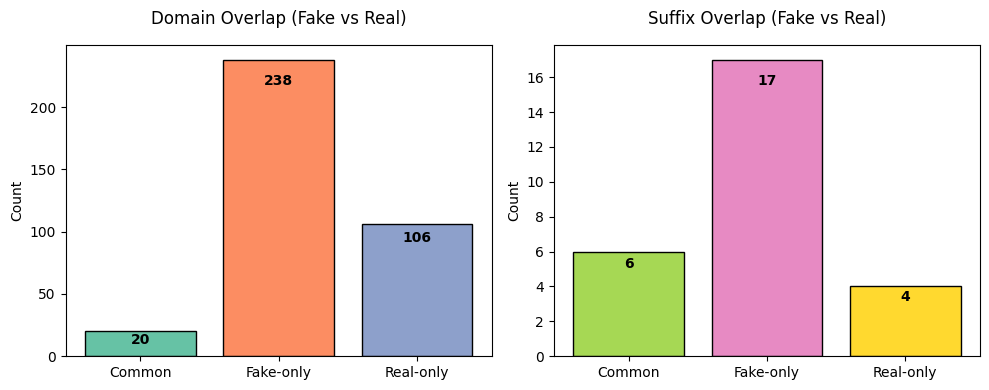

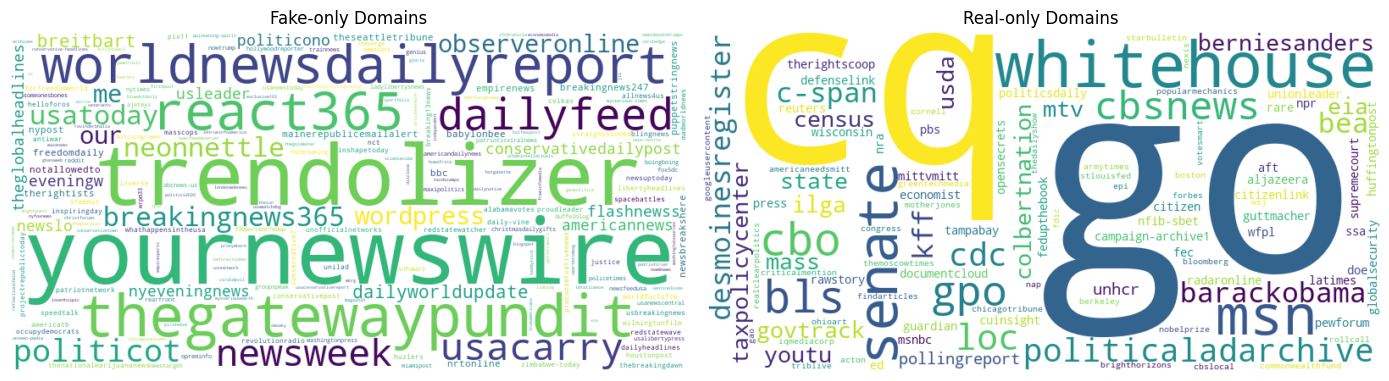

In [15]:
# --- VISUAL SUMMARY (with corrected label placement) ---
labels = ["Common", "Fake-only", "Real-only"]
domain_counts = [
    len(common_domains),
    len(unique_fake_domains),
    len(unique_real_domains),
]
suffix_counts = [
    len(common_suffixes),
    len(unique_fake_suffixes),
    len(unique_real_suffixes),
]

domain_colors = ["#66c2a5", "#fc8d62", "#8da0cb"]
suffix_colors = ["#a6d854", "#e78ac3", "#ffd92f"]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Domain overlap
axs[0].bar(labels, domain_counts, color=domain_colors, edgecolor="black")
axs[0].set_title("Domain Overlap (Fake vs Real)", pad=15)
axs[0].set_ylabel("Count")
for i, v in enumerate(domain_counts):
    axs[0].text(
        i,
        v - (v * 0.05),
        str(v),
        ha="center",
        va="top",
        fontweight="bold",
        color="black",
    )

# Suffix overlap
axs[1].bar(labels, suffix_counts, color=suffix_colors, edgecolor="black")
axs[1].set_title("Suffix Overlap (Fake vs Real)", pad=15)
axs[1].set_ylabel("Count")
for i, v in enumerate(suffix_counts):
    axs[1].text(
        i,
        v - (v * 0.05),
        str(v),
        ha="center",
        va="top",
        fontweight="bold",
        color="black",
    )

plt.tight_layout()
plt.show()


# --- FILTER DOMAINS: EXCLUDE COMMON + EMPTY ---
fake_domain_series = politics_fake_df.loc[
    (~politics_fake_df["domain"].isin(common_domains))
    & (politics_fake_df["domain"] != ""),
    "domain",
]

real_domain_series = politics_real_df.loc[
    (~politics_real_df["domain"].isin(common_domains))
    & (politics_real_df["domain"] != ""),
    "domain",
]

# Frequency dicts for word clouds
fake_domain_freq = fake_domain_series.value_counts().to_dict()
real_domain_freq = real_domain_series.value_counts().to_dict()


# --- WORD CLOUDS ---
wc_fake = WordCloud(
    width=800, height=400, background_color="white"
).generate_from_frequencies(fake_domain_freq)

wc_real = WordCloud(
    width=800, height=400, background_color="white"
).generate_from_frequencies(real_domain_freq)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Fake news Domains
axs[0].imshow(wc_fake, interpolation="bilinear")
axs[0].axis("off")
axs[0].set_title("Fake-only Domains")

# Real news Domains
axs[1].imshow(wc_real, interpolation="bilinear")
axs[1].axis("off")
axs[1].set_title("Real-only Domains")

plt.tight_layout()
plt.show()

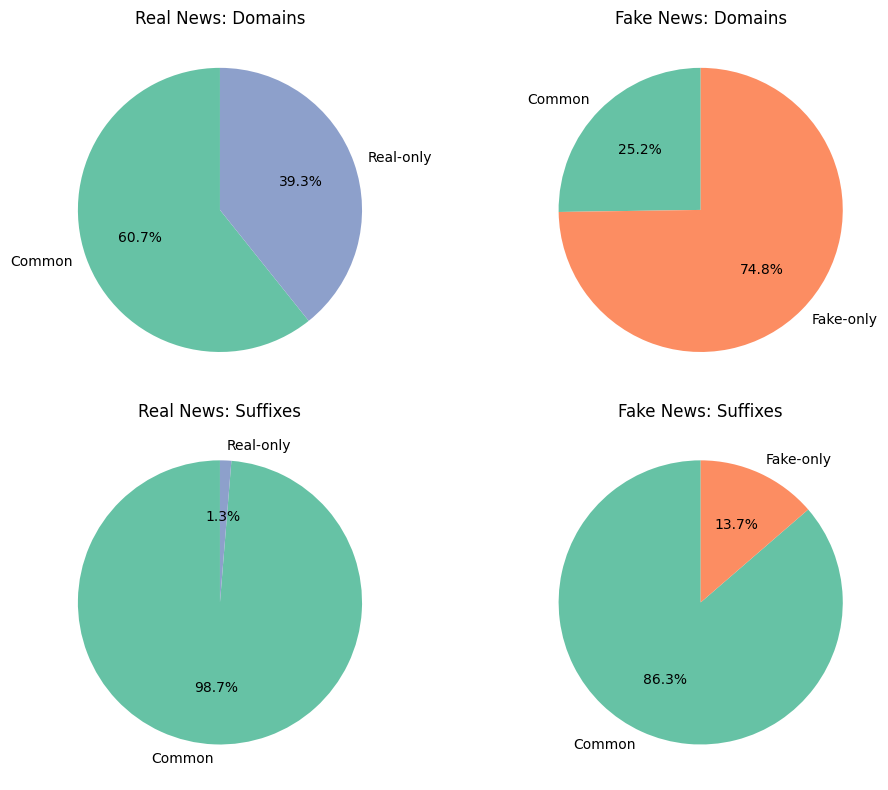

In [16]:
# Calculate proportions for domains
real_common_domains_pct = politics_real_df["domain"].isin(common_domains).mean() * 100
real_unique_domains_pct = 100 - real_common_domains_pct

fake_common_domains_pct = politics_fake_df["domain"].isin(common_domains).mean() * 100
fake_unique_domains_pct = 100 - fake_common_domains_pct

# Calculate proportions for suffixes
real_common_suffixes_pct = politics_real_df["suffix"].isin(common_suffixes).mean() * 100
real_unique_suffixes_pct = 100 - real_common_suffixes_pct

fake_common_suffixes_pct = politics_fake_df["suffix"].isin(common_suffixes).mean() * 100
fake_unique_suffixes_pct = 100 - fake_common_suffixes_pct
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # 2 rows, 2 columns

# --- Row 1 ---
# Real News: Domains
axs[0, 0].pie(
    [real_common_domains_pct, real_unique_domains_pct],
    labels=["Common", "Real-only"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#8da0cb"],
    startangle=90,
)
axs[0, 0].set_title("Real News: Domains")

# Fake News: Domains
axs[0, 1].pie(
    [fake_common_domains_pct, fake_unique_domains_pct],
    labels=["Common", "Fake-only"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
)
axs[0, 1].set_title("Fake News: Domains")

# --- Row 2 ---
# Real News: Suffixes
axs[1, 0].pie(
    [real_common_suffixes_pct, real_unique_suffixes_pct],
    labels=["Common", "Real-only"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#8da0cb"],
    startangle=90,
)
axs[1, 0].set_title("Real News: Suffixes")

# Fake News: Suffixes
axs[1, 1].pie(
    [fake_common_suffixes_pct, fake_unique_suffixes_pct],
    labels=["Common", "Fake-only"],
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62"],
    startangle=90,
)
axs[1, 1].set_title("Fake News: Suffixes")

# Adjust spacing between rows and columns
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.tight_layout()
plt.show()

In [17]:
# Create binary columns for real-only and fake-only domains
politics_real_df["real_only_domain"] = politics_real_df["domain"].apply(
    lambda x: 1 if x in unique_real_domains else 0
)
politics_fake_df["real_only_domain"] = politics_fake_df["domain"].apply(
    lambda x: 1 if x in unique_real_domains else 0
)

politics_real_df["fake_only_domain"] = politics_real_df["domain"].apply(
    lambda x: 1 if x in unique_fake_domains else 0
)
politics_fake_df["fake_only_domain"] = politics_fake_df["domain"].apply(
    lambda x: 1 if x in unique_fake_domains else 0
)

#### Explore Data (Domains)

Analysis of the urls paints a clear picture of the differences between real and fake news. While NLPs can identify text patterns, domains can provide a quick heuristic to identify fake news.

For clarity, the domain is the main part of the URL, i.e. "cnn" in "www.cnn.com". The suffix is the ending of the URL, i.e. "com" in "www.cnn.com". If the "cnn" domain is present in the fake news dataset, it is a common domain. If it is only present in the fake news dataset, it is a fake-only domain and if it is only present in the real news dataset, it is a real-only domain. The same logic applies to suffixes.

There are common suffix between real and fake news, but there are also many unique suffixes. As expected, the fake news dataset contains foreign government such as "rt" (Russia), "is" (Iceland), and "gov.jm" (Jamaica).

If we search for domains and suffixes that are unique to either dataset, the only useful pattern is fake-only domains. 75% of all fake news comes from domains that are unique to fake news. We cannot reliably predict based on real-only domains as 60% of real news uses common domains.


#### Explore Data (Title)


Article titles provide minimal text compared to the article itself, but this data can be crucial in idenfting fake news. For example, it's highly unlikely that a shocking title would have mundane text and vice versa. Shocking titles accompany shocking text. We expect fake news articles to be more engaging, shocking, and inflamatory. The question is whether or not an NLP will pick up on these patterns.


--- Real ---
       textblob_polarity  vader_compound
count         624.000000      624.000000
mean            0.038518        0.015800
std             0.161547        0.282908
min            -0.700000       -0.959000
25%             0.000000        0.000000
50%             0.000000        0.000000
75%             0.000000        0.000000
max             1.000000        0.844200 

--- Fake ---
       textblob_polarity  vader_compound
count         432.000000      432.000000
mean            0.005980       -0.162425
std             0.222265        0.398981
min            -1.000000       -0.942300
25%             0.000000       -0.510600
50%             0.000000        0.000000
75%             0.000000        0.000000
max             0.900000        0.942300 



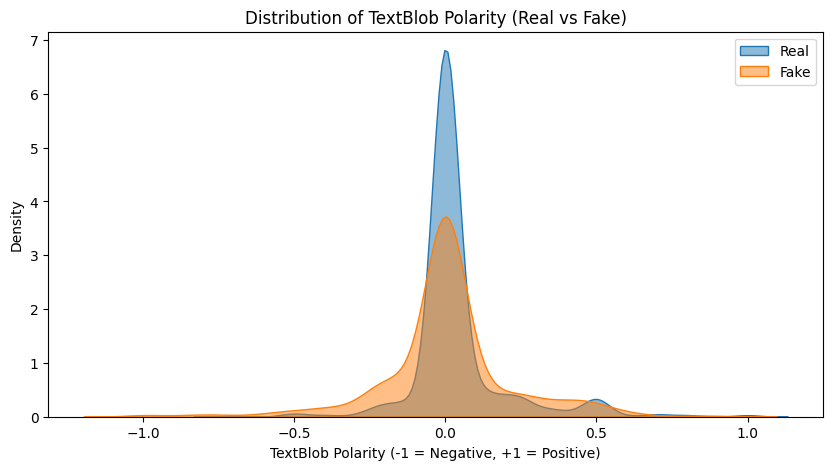

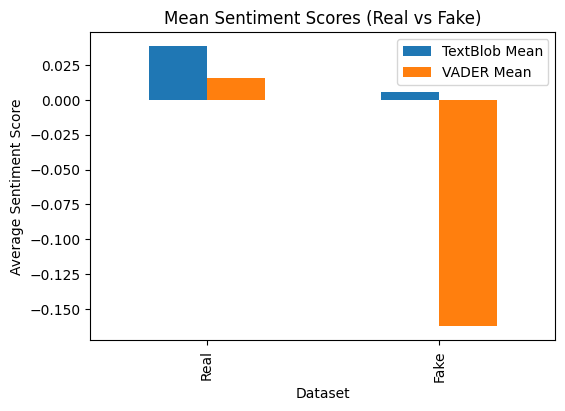

Real correlation: 0.225
Fake correlation: 0.323
TextBlob polarity difference: TtestResult(statistic=2.754256687940033, pvalue=0.005983787382996053, df=1054.0)
VADER compound difference: TtestResult(statistic=8.493426981968938, pvalue=6.752670826488444e-17, df=1054.0)


In [18]:
# --- SENTIMENT ANALYSIS ---
analyzer = SentimentIntensityAnalyzer()  # Import from VADER to use alongside TextBlob


# We'll compare two major libraries for sentiment analysis: TextBlob and VADER
for df in [politics_real_df, politics_fake_df]:
    df["textblob_polarity"] = df["title"].apply(
        lambda x: TextBlob(str(x)).sentiment.polarity
    )
    df["vader_compound"] = df["title"].apply(
        lambda x: analyzer.polarity_scores(str(x))["compound"]
    )

# Describe polarity and
for label, df in [("Real", politics_real_df), ("Fake", politics_fake_df)]:
    print(f"--- {label} ---")
    print(df[["textblob_polarity", "vader_compound"]].describe(), "\n")

# We can visualize the distributions of sentiment scores for both datasets using bar chart, but with negative Y-axis
plt.figure(figsize=(10, 5))
sns.kdeplot(politics_real_df["textblob_polarity"], label="Real", fill=True, alpha=0.5)
sns.kdeplot(politics_fake_df["textblob_polarity"], label="Fake", fill=True, alpha=0.5)
plt.title("Distribution of TextBlob Polarity (Real vs Fake)")
plt.xlabel("TextBlob Polarity (-1 = Negative, +1 = Positive)")
plt.legend()
plt.show()

# Construct a DataFrame to hold mean sentiment scores for both datasets. Also hold the real and fake labels to avoid the tuples from earlier
# Creating a dataframe made it easier to plot the means
means = {
    "Dataset": ["Real", "Fake"],
    "TextBlob Mean": [
        politics_real_df["textblob_polarity"].mean(),
        politics_fake_df["textblob_polarity"].mean(),
    ],
    "VADER Mean": [
        politics_real_df["vader_compound"].mean(),
        politics_fake_df["vader_compound"].mean(),
    ],
}

mean_df = pd.DataFrame(means).set_index("Dataset")
mean_df.plot(kind="bar", figsize=(6, 4), title="Mean Sentiment Scores (Real vs Fake)")
plt.ylabel("Average Sentiment Score")
plt.show()

# Correlation between TextBlob and VADER scores within each dataset
for label, df in [("Real", politics_real_df), ("Fake", politics_fake_df)]:
    # Compute the correlation and print results
    corr = df["textblob_polarity"].corr(df["vader_compound"])
    print(f"{label} correlation: {corr:.3f}")

# To further assess differences, we can perform t-tests on the sentiment scores between real and fake datasets
t1 = ttest_ind(
    politics_real_df["textblob_polarity"],
    politics_fake_df["textblob_polarity"],
    nan_policy="omit",
)
t2 = ttest_ind(
    politics_real_df["vader_compound"],
    politics_fake_df["vader_compound"],
    nan_policy="omit",
)

print("TextBlob polarity difference:", t1)
print("VADER compound difference:", t2)

As shown in the visualizations, TextBlob polarity scores cluster more strongly around zero for real news, suggesting a balanced emotional tone. In contrast, fake news exhibits a wider, more extreme polarity distribution, reflecting its tendency toward emotionally charged or sensational titles.

The bar chart comparing TextBlob and VADER sentiment highlights clear differences between the two methods. VADER reveals stronger negative sentiment values, indicating its heightened sensitivity to emotionally loaded language. This observation is reinforced by the T-test results: while TextBlob’s p-value is below 0.05 (showing statistical significance), VADER’s p-value approaches zero—confirming a highly significant difference in sentiment between real and fake news when evaluated with VADER.


There are still some general features we can create, such as the number of capital letters, number of exclamation points, number of words, and number of characters. These features can help us identify sensationalized titles that are common in fake news.


In [19]:
# Add a column for the number of capital letters in each title
politics_real_df["num_capitals"] = (
    politics_real_df["title"]
    .apply(lambda x: sum(1 for c in str(x) if c.isupper()))
    .astype(int)
)
politics_fake_df["num_capitals"] = (
    politics_fake_df["title"]
    .apply(lambda x: sum(1 for c in str(x) if c.isupper()))
    .astype(int)
)

# Add a column for the number of exclamation marks in each title
politics_fake_df["num_exclamations"] = politics_fake_df["title"].apply(
    lambda x: str(x).count("!")
)
politics_real_df["num_exclamations"] = politics_real_df["title"].apply(
    lambda x: str(x).count("!")
)

# Add a column for the number of words in each title
politics_real_df["num_words"] = (
    politics_real_df["title"].apply(lambda x: len(str(x).split())).astype(int)
)
politics_fake_df["num_words"] = (
    politics_fake_df["title"].apply(lambda x: len(str(x).split())).astype(int)
)

# Add a column for the number of characters in each title
politics_real_df["num_characters"] = (
    politics_real_df["title"].apply(lambda x: len(str(x))).astype(int)
)
politics_fake_df["num_characters"] = (
    politics_fake_df["title"].apply(lambda x: len(str(x))).astype(int)
)

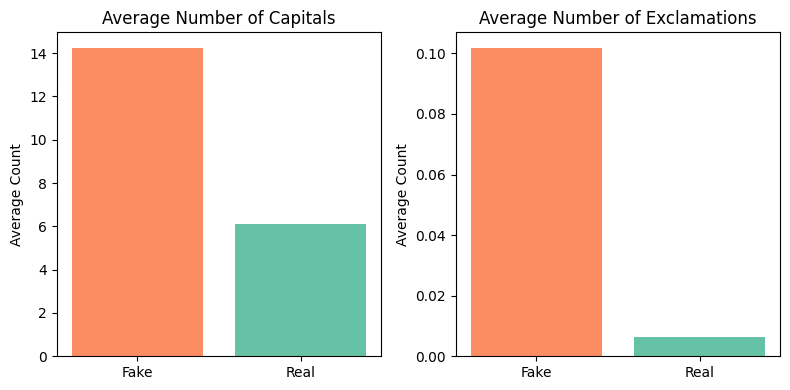

In [20]:
# Calculate averages
fake_avg_caps = politics_fake_df["num_capitals"].mean()
real_avg_caps = politics_real_df["num_capitals"].mean()

fake_avg_excl = politics_fake_df["num_exclamations"].mean()
real_avg_excl = politics_real_df["num_exclamations"].mean()

# Plot
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Capitals
axs[0].bar(
    ["Fake", "Real"], [fake_avg_caps, real_avg_caps], color=["#fc8d62", "#66c2a5"]
)
axs[0].set_title("Average Number of Capitals")
axs[0].set_ylabel("Average Count")

# Exclamations
axs[1].bar(
    ["Fake", "Real"], [fake_avg_excl, real_avg_excl], color=["#fc8d62", "#66c2a5"]
)
axs[1].set_title("Average Number of Exclamations")
axs[1].set_ylabel("Average Count")

plt.tight_layout()
plt.show()

In [21]:
politics_real_df.to_csv("politics_real_df.csv", index=False)
politics_fake_df.to_csv("politics_fake_df.csv", index=False)

In [22]:
# Combine real and fake dataframes
politics_real_df["real"] = 1
politics_fake_df["real"] = 0
combined_df = pd.concat([politics_real_df, politics_fake_df], ignore_index=True)

# Fill missing titles with empty string to avoid errors in TfidfVectorizer
combined_df["title"] = combined_df["title"].fillna("")

# Prepare features and target
X = combined_df[
    [
        "domain",
        "suffix",
        "textblob_polarity",
        "vader_compound",
        "title",
        "num_capitals",
        "num_exclamations",
        "num_words",
        "num_characters",
        "real_only_domain",
    ]
]
y = combined_df["real"]

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define which columns are categorical vs numeric
cat_features = ["domain", "suffix"]
num_features = [
    "textblob_polarity",
    "vader_compound",
    "num_capitals",
    "num_exclamations",
    "num_words",
    "num_characters",
    "real_only_domain",
]
text_feature = "title"

# Preprocess: one-hot encode categoricals, pass through numerics, TF-IDF for text
preprocess = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features),
        (
            "text",
            TfidfVectorizer(
                ngram_range=(1, 2), min_df=5, max_features=1000, stop_words="english"
            ),
            text_feature,
        ),
    ]
)

# ================= XGBoost (Grid Search) =================
# XGBoost classifier: objective=logistic for binary output probability;
# random_state ensures reproducibility; eval_metric='logloss' aligns with probabilistic classification;
# use_label_encoder=False avoids deprecated label encoding path.
xgb_clf = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss",  # Penalizes miscalibrated probabilities; stable for binary tasks
    use_label_encoder=False,  # Modern API usage
)
# Pipeline: keeps preprocessing + model coupled for GridSearchCV so CV folds apply identical transforms.
pipeline_xgb = Pipeline([("preprocess", preprocess), ("xgb", xgb_clf)])

# Hyperparameter grid kept compact to control runtime (dataset size is moderate) while spanning bias-variance tradeoffs:
# n_estimators: small to moderate values—higher can overfit and slow training; 120 upper bound is sufficient here.
# learning_rate: typical conservative to moderately aggressive values to test convergence speed vs. generalization.
# max_depth: shallow (3) to moderate (6) to explore model complexity without extreme overfitting risk.
# subsample: <1.0 introduces stochasticity to reduce overfitting; 1.0 retains deterministic full sampling.
# colsample_bytree: feature subsampling improves generalization; 0.8 vs 1.0 contrasts regularization effect.
param_grid = {
    "xgb__n_estimators": [20, 50, 100, 120],
    "xgb__learning_rate": [0.05, 0.1, 0.2],
    "xgb__max_depth": [3, 4, 6],
    "xgb__subsample": [0.8, 1.0],
    "xgb__colsample_bytree": [0.8, 1.0],
}
grid_search = GridSearchCV(
    pipeline_xgb, param_grid=param_grid, cv=5, scoring="accuracy", verbose=1, n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_xgb = grid_search.best_estimator_
print("Best XGBoost Parameters:", grid_search.best_params_)
y_pred_xgb = best_xgb.predict(X_test)

# ================= Logistic Regression =================
log_reg_clf = LogisticRegression(max_iter=2000) # Increased max_iter for convergence
pipeline_lr = Pipeline([("preprocess", preprocess), ("lr", log_reg_clf)]) 
pipeline_lr.fit(X_train, y_train)
y_pred_lr = pipeline_lr.predict(X_test)

# ================= Linear SVC =================
svc_clf = LinearSVC()
pipeline_svc = Pipeline([("preprocess", preprocess), ("svc", svc_clf)])
pipeline_svc.fit(X_train, y_train)
y_pred_svc = pipeline_svc.predict(X_test)

# ================= Reports =================
print("\n=== Classification Report: XGBoost ===")
print(
    classification_report(
        y_test, y_pred_xgb, target_names=["Fake (0)", "Real (1)"], digits=3
    )
)
print("\n=== Classification Report: Logistic Regression ===")
print(
    classification_report(
        y_test, y_pred_lr, target_names=["Fake (0)", "Real (1)"], digits=3
    )
)
print("\n=== Classification Report: LinearSVC ===")
print(
    classification_report(
        y_test, y_pred_svc, target_names=["Fake (0)", "Real (1)"], digits=3
    )
)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best XGBoost Parameters: {'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 3, 'xgb__n_estimators': 100, 'xgb__subsample': 1.0}

=== Classification Report: XGBoost ===
              precision    recall  f1-score   support

    Fake (0)      0.840     0.908     0.873        87
    Real (1)      0.932     0.880     0.905       125

    accuracy                          0.892       212
   macro avg      0.886     0.894     0.889       212
weighted avg      0.895     0.892     0.892       212


=== Classification Report: Logistic Regression ===
              precision    recall  f1-score   support

    Fake (0)      0.894     0.874     0.884        87
    Real (1)      0.913     0.928     0.921       125

    accuracy                          0.906       212
   macro avg      0.904     0.901     0.902       212
weighted avg      0.905     0.906     0.905       212


=== Classification Report: LinearSVC 

In [25]:
# Our best performing model was LinearCSV with almost 93% accuracy in classifying fake news. 

In [24]:
# LinearSVC does not provide feature importance directly, but we can access the absolute value of the coefficients.
# We'll align them with feature names from the preprocessor.


# Get feature names from the preprocessor
cat_features = ["domain", "suffix"]
num_features = [
    "textblob_polarity",
    "vader_compound",
    "num_capitals",
    "num_exclamations",
    "num_words",
    "num_characters",
    "real_only_domain",
]
text_feature = "title"

# Get feature names for each transformer
ohe = pipeline_svc.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_features)

tfidf = pipeline_svc.named_steps["preprocess"].named_transformers_["text"]
tfidf_feature_names = tfidf.get_feature_names_out()

all_feature_names = np.concatenate([
    cat_feature_names,
    num_features,
    tfidf_feature_names
])

# Get coefficients from the LinearSVC model
svc_coef = pipeline_svc.named_steps["svc"].coef_.flatten()
feature_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": np.abs(svc_coef)
}).sort_values("importance", ascending=False)

print(feature_importance_df.head(20))

                   feature  importance
334       real_only_domain    1.635964
176         domain_nytimes    1.337212
302         domain_youtube    1.195901
95          domain_foxnews    1.060886
198      domain_politifact    1.056637
257            domain_time    0.994571
357               breaking    0.940211
141          domain_medium    0.929553
151         domain_nbcnews    0.850904
286  domain_washingtonpost    0.845244
17          domain_archive    0.814848
51              domain_cnn    0.792740
263         domain_twitter    0.788056
193        domain_politico    0.769580
403                florida    0.689172
306                suffix_    0.667491
0                  domain_    0.667491
426                   just    0.572135
432                 letter    0.520095
18         domain_archives    0.514927
